# Dự án: Phân tích ứng dụng Google Play Store
## Đề tài: Khảo sát, tiền xử lý và mô hình hóa dữ liệu Google Play Store
### Notebook 04: Phân tích khám phá & Trực quan hóa dữ liệu (04_eda_visualization.ipynb)

**Mục tiêu:** Khám phá các đặc trưng phân phối, mối tương quan giữa các biến số và xu hướng theo nhóm trên tập dữ liệu đã làm sạch (`train.csv`), nhằm rút ra insight phục vụ bước Feature Engineering (05) và Machine Learning (06).

# I. Đọc dữ liệu đã làm sạch (Train Set)

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== CHẨN ĐOÁN HỆ THỐNG & ĐƯỜNG DẪN ===")
print("Thư mục đang chạy (getcwd):", os.getcwd())
if os.path.exists('.'):
    print("Các tệp ở thư mục hiện tại:", os.listdir('.'))

# Tự động quét tìm đường dẫn tương đối chuẩn xác nhất cho thư mục processed
def get_processed_dir():
    candidates = [
        os.path.join("..", "data", "processed"),
        os.path.join("data", "processed"),
        os.path.join("Du_AN", "data", "processed"),
        os.path.join("..", "Du_AN", "data", "processed")
    ]
    if os.name != 'nt':
        win_path = r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed"
        wsl_path = win_path.replace("\\", "/")
        if len(wsl_path) > 2 and wsl_path[1] == ':':
            wsl_path = f"/mnt/{wsl_path[0].lower()}{wsl_path[2:]}"
        candidates.insert(0, wsl_path)
    curr = os.getcwd()
    for _ in range(5):
        for c in candidates:
            if os.path.exists(c):
                print(f"Tìm thấy thư mục processed tại: {c}")
                return c
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    print("CẢNH BÁO: Không tìm thấy thư mục processed. Dùng đường dẫn mặc định.")
    return os.path.join("..", "data", "processed")

processed_dir = get_processed_dir()
train_path = os.path.join(processed_dir, "train.csv")
test_path = os.path.join(processed_dir, "test.csv")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"\nTập Train: {df_train.shape} | Tập Test: {df_test.shape}")
df_train.head(3)

=== CHẨN ĐOÁN HỆ THỐNG & ĐƯỜNG DẪN ===
Thư mục đang chạy (getcwd): e:\Du_AN\notebooks
Các tệp ở thư mục hiện tại: ['01_data_understanding.ipynb', '02_postgresql_pipeline.ipynb', '03_data_cleaning.ipynb', '04_eda_visualization.ipynb', '05_feature_engineering.ipynb', '06_machine_learning.ipynb', '07_prediction_demo.ipynb']
Tìm thấy thư mục processed tại: ..\data\processed

Tập Train: (7727, 15) | Tập Test: (1932, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity
0,4x4 Jeep Racer,GAME,4.1,7279,54.0,1000000,Free,0.0,Everyone,Racing,"March 9, 2018",1.5,4.0 and up,0.000000,0.000000
1,DF-CAM,TOOLS,4.2,2,20.0,100,Free,0.0,Everyone,Tools,"May 16, 2018",2.0.1,4.3 and up,0.000000,0.000000
2,BBW Dating & Plus Size Chat,DATING,4.4,12633,29.0,1000000,Free,0.0,Mature 17+,Dating,"July 27, 2018",3.5.0.1,4.1 and up,0.131247,0.491017


**Nhận xét:**
- Nạp thành công tập Train gồm 7,727 ứng dụng và tập Test gồm 1,932 ứng dụng, đã qua làm sạch ở Notebook 03.
- Toàn bộ EDA bên dưới thực hiện trên **tập Train** để tránh rò rỉ thông tin (data leakage) sang tập Test dùng cho đánh giá mô hình.

# II. Phân tích đơn biến (Univariate Analysis)

## 1. Phân phối biến mục tiêu Rating

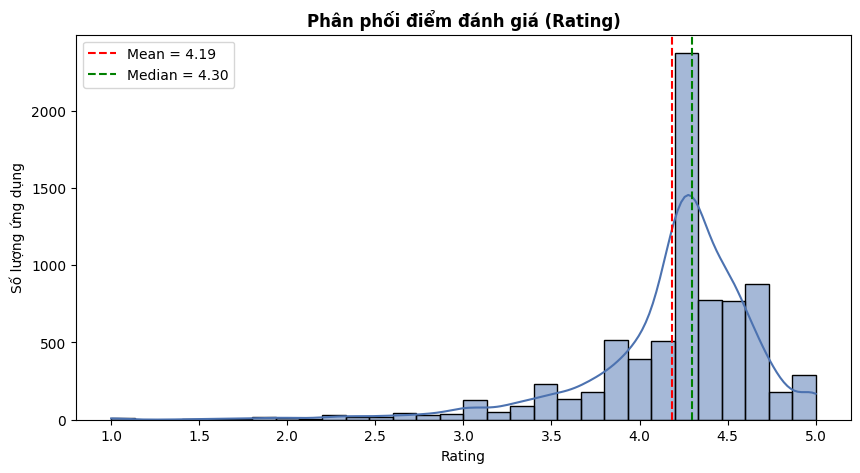

count    7727.000000
mean        4.185544
std         0.502218
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['Rating'], bins=30, kde=True, color='#4C72B0')
plt.axvline(df_train['Rating'].mean(), color='red', linestyle='--', label=f"Mean = {df_train['Rating'].mean():.2f}")
plt.axvline(df_train['Rating'].median(), color='green', linestyle='--', label=f"Median = {df_train['Rating'].median():.2f}")
plt.title("Phân phối điểm đánh giá (Rating)", fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Số lượng ứng dụng")
plt.legend()
plt.show()

print(df_train['Rating'].describe())

**Nhận xét:**
- Rating có phân phối lệch trái (skewed left), tập trung dày đặc trong khoảng 4.0 - 4.5.
- Rating trung bình đạt 4.19, trung vị 4.30, cho thấy phần lớn ứng dụng trên Google Play được người dùng đánh giá khá tích cực.

## 2. Phân phối biến Installs (số lượt cài đặt)

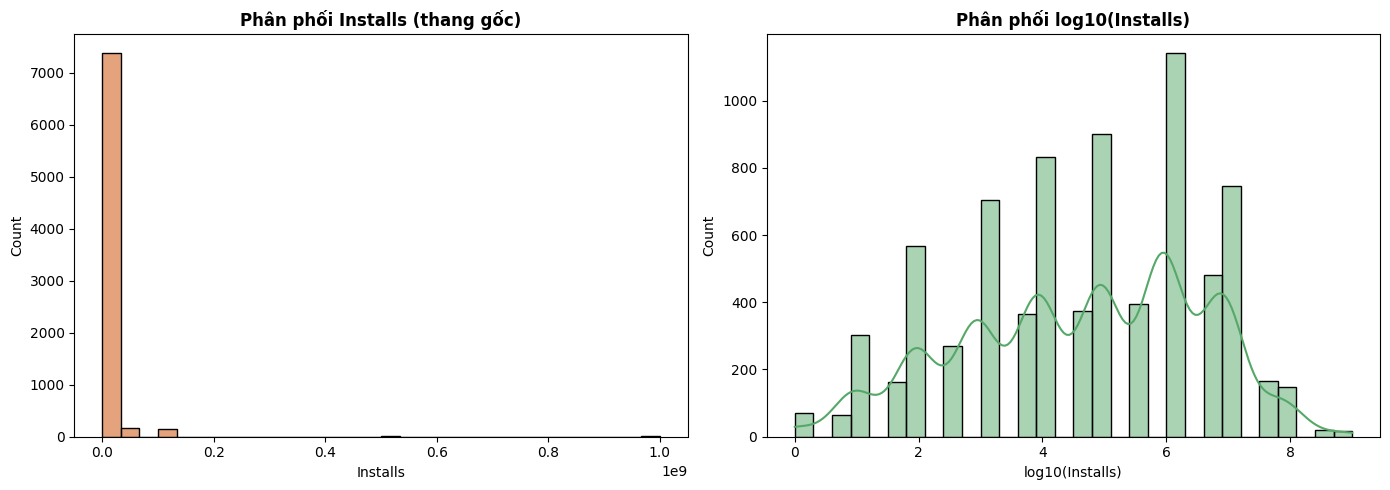

Độ lệch (skewness) của Installs: 14.61


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_train['Installs'], bins=30, color='#DD8452', ax=axes[0])
axes[0].set_title("Phân phối Installs (thang gốc)", fontweight='bold')
axes[0].set_xlabel("Installs")

# Log-transform vì Installs lệch phải rất mạnh (skew cao)
log_installs = np.log10(df_train['Installs'].replace(0, 1))
sns.histplot(log_installs, bins=30, kde=True, color='#55A868', ax=axes[1])
axes[1].set_title("Phân phối log10(Installs)", fontweight='bold')
axes[1].set_xlabel("log10(Installs)")

plt.tight_layout()
plt.show()

print(f"Độ lệch (skewness) của Installs: {df_train['Installs'].skew():.2f}")

**Nhận xét:**
- Installs có độ lệch cực lớn (skewness ≈ 14.6), tuyệt đại đa số ứng dụng có lượt cài đặt thấp trong khi một số ít "ứng dụng bom tấn" có hàng trăm triệu đến 1 tỷ lượt cài.
- Sau khi biến đổi log10, phân phối trở nên gần chuẩn hơn nhiều → đây là gợi ý quan trọng để áp dụng log-transform ở bước Feature Engineering (05).

## 3. Phân phối theo Category, Type & Content Rating

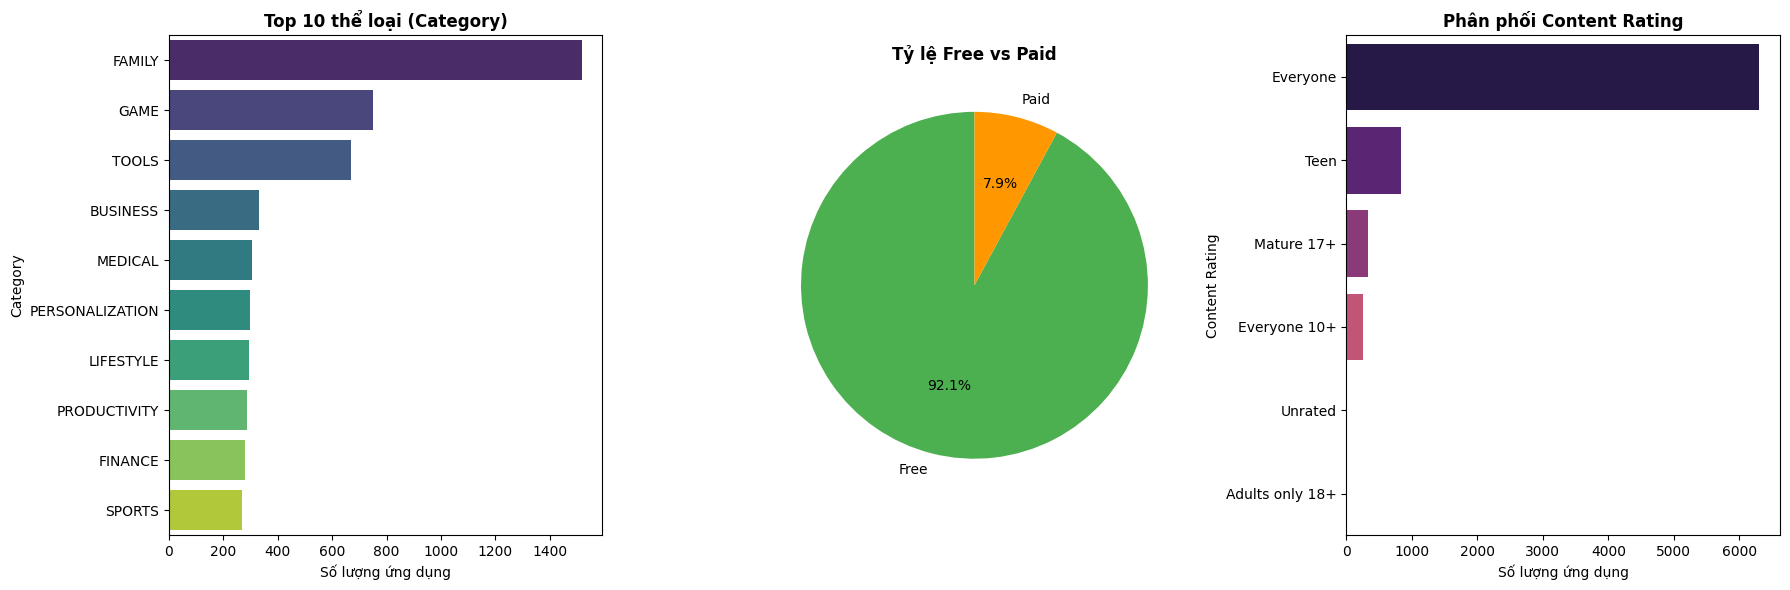

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_cat = df_train['Category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, hue=top_cat.index, legend=False, palette='viridis', ax=axes[0])
axes[0].set_title("Top 10 thể loại (Category)", fontweight='bold')
axes[0].set_xlabel("Số lượng ứng dụng")

type_counts = df_train['Type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#FF9800'], startangle=90)
axes[1].set_title("Tỷ lệ Free vs Paid", fontweight='bold')

cr_counts = df_train['Content Rating'].value_counts()
sns.barplot(x=cr_counts.values, y=cr_counts.index, hue=cr_counts.index, legend=False, palette='magma', ax=axes[2])
axes[2].set_title("Phân phối Content Rating", fontweight='bold')
axes[2].set_xlabel("Số lượng ứng dụng")

plt.tight_layout()
plt.show()

**Nhận xét:**
- `FAMILY` và `GAME` là hai thể loại chiếm số lượng ứng dụng lớn nhất trên kho ứng dụng.
- Ứng dụng miễn phí (Free) áp đảo với khoảng 92% (7,128/7,727), chỉ ~8% ứng dụng trả phí (Paid).
- Phần lớn ứng dụng (khoảng 82%) hướng đến đối tượng `Everyone`, các mức giới hạn độ tuổi cao như `Adults only 18+` hay `Unrated` rất hiếm gặp.

# III. Phân tích tương quan (Bivariate/Correlation Analysis)

## 1. Ma trận tương quan giữa các biến số

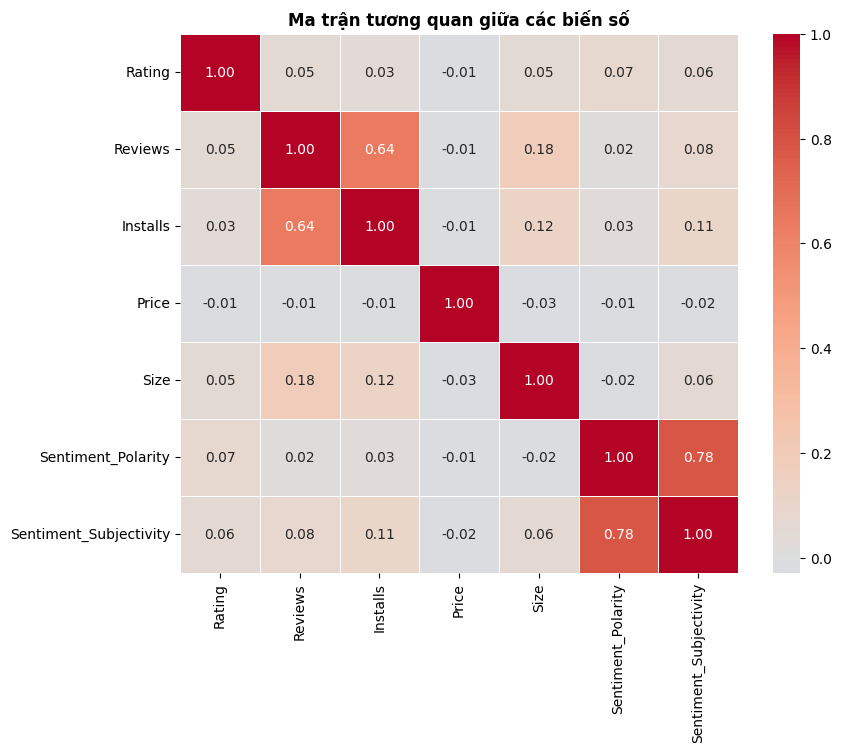

In [5]:
num_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size',
            'Sentiment_Polarity', 'Sentiment_Subjectivity']
corr_matrix = df_train[num_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến số", fontweight='bold')
plt.show()

**Nhận xét:**
- Rating hầu như không tương quan tuyến tính mạnh với bất kỳ biến số nào (hệ số cao nhất chỉ ~0.07 với Sentiment_Polarity), cho thấy dự báo Rating là bài toán khó, cần các đặc trưng phi tuyến hoặc phân loại (Category, Genres...).
- `Sentiment_Polarity` và `Sentiment_Subjectivity` tương quan khá mạnh với nhau (0.78) vì cùng phản ánh sắc thái cảm xúc của review.
- `Reviews` và `Installs` thường có tương quan dương đáng kể trong các phân tích Google Play Store (ứng dụng càng nhiều lượt tải thường càng nhiều lượt đánh giá).

## 2. Rating theo Category (Top & Bottom)

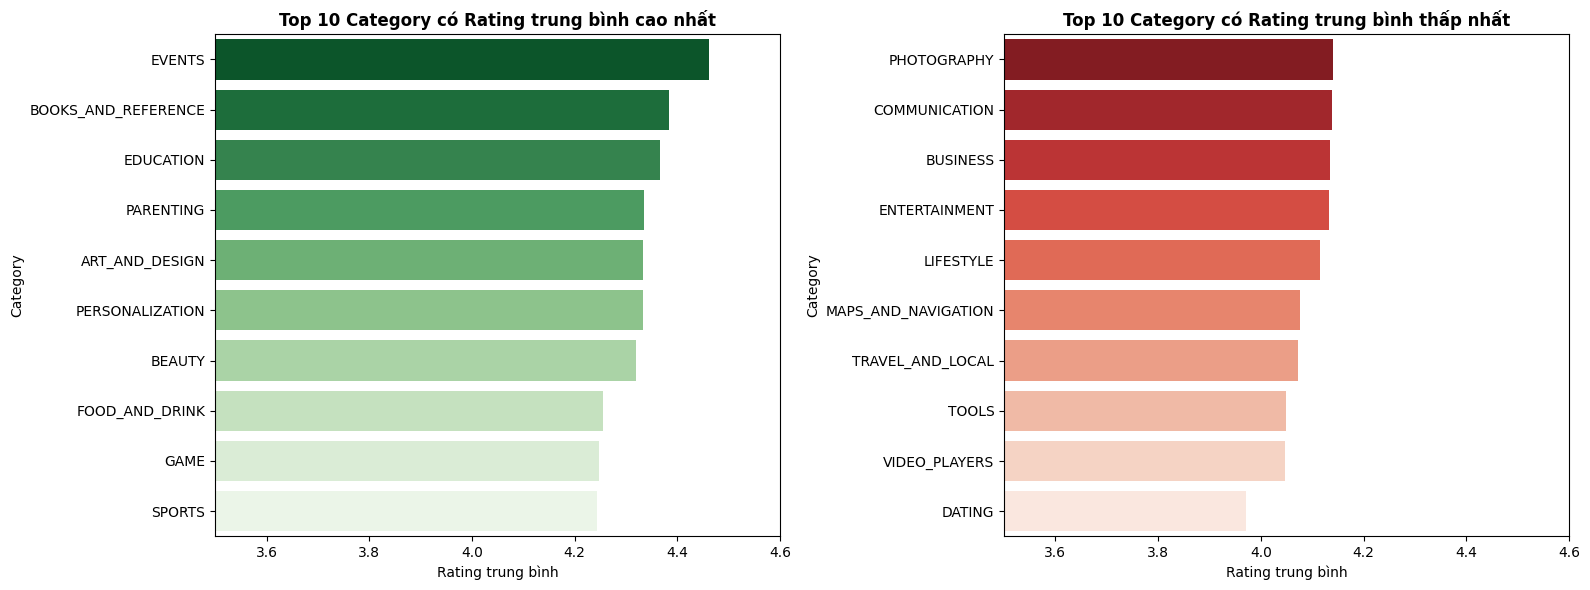

In [6]:
cat_rating = df_train.groupby('Category')['Rating'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=cat_rating.head(10).values, y=cat_rating.head(10).index,
            hue=cat_rating.head(10).index, legend=False, palette='Greens_r', ax=axes[0])
axes[0].set_title("Top 10 Category có Rating trung bình cao nhất", fontweight='bold')
axes[0].set_xlim(3.5, 4.6)
axes[0].set_xlabel("Rating trung bình")

sns.barplot(x=cat_rating.tail(10).values, y=cat_rating.tail(10).index,
            hue=cat_rating.tail(10).index, legend=False, palette='Reds_r', ax=axes[1])
axes[1].set_title("Top 10 Category có Rating trung bình thấp nhất", fontweight='bold')
axes[1].set_xlim(3.5, 4.6)
axes[1].set_xlabel("Rating trung bình")

plt.tight_layout()
plt.show()

**Nhận xét:**
- `EVENTS`, `BOOKS_AND_REFERENCE`, `ART_AND_DESIGN` là các thể loại có Rating trung bình cao nhất (~4.37 - 4.43).
- `DATING`, `TOOLS`, `MAPS_AND_NAVIGATION` nằm trong nhóm Rating trung bình thấp nhất, có thể do đặc thù ứng dụng dễ gây trải nghiệm khó chịu hoặc kỳ vọng người dùng cao hơn.
- Chênh lệch giữa nhóm cao nhất và thấp nhất không quá lớn (~0.36 điểm) nhưng vẫn đủ để `Category` trở thành đặc trưng phân loại hữu ích.

## 3. Installs trung bình theo Category

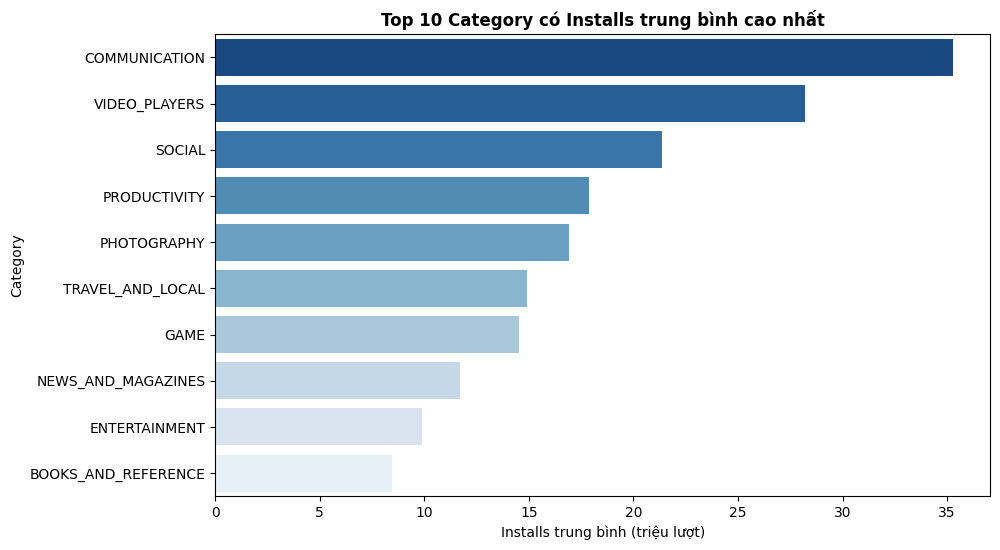

In [7]:
cat_installs = df_train.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_installs.values / 1e6, y=cat_installs.index,
            hue=cat_installs.index, legend=False, palette='Blues_r')
plt.title("Top 10 Category có Installs trung bình cao nhất", fontweight='bold')
plt.xlabel("Installs trung bình (triệu lượt)")
plt.show()

**Nhận xét:**
- `COMMUNICATION` và `VIDEO_PLAYERS` dẫn đầu về lượt cài đặt trung bình (36 triệu và 27.8 triệu lượt/ứng dụng), phản ánh nhu cầu sử dụng hằng ngày rất lớn.
- Nhóm ứng dụng mạng xã hội (`SOCIAL`), năng suất (`PRODUCTIVITY`) và chụp ảnh (`PHOTOGRAPHY`) cũng nằm trong top do tính phổ biến và được cài sẵn/đề xuất nhiều trên thiết bị Android.

## 4. Free vs Paid: So sánh Rating

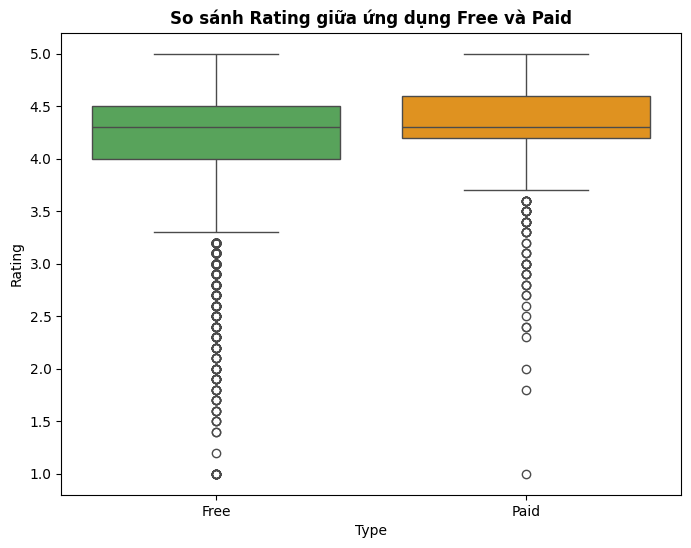

          mean  median  count
Type                         
Free  4.177423     4.3   7118
Paid  4.280460     4.3    609


In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Rating', hue='Type', data=df_train, legend=False, palette=['#4CAF50', '#FF9800'])
plt.title("So sánh Rating giữa ứng dụng Free và Paid", fontweight='bold')
plt.show()

print(df_train.groupby('Type')['Rating'].agg(['mean', 'median', 'count']))

**Nhận xét:**
- Ứng dụng trả phí (Paid) có Rating trung bình nhỉnh hơn (4.27) so với ứng dụng miễn phí (4.18), có thể do người dùng trả tiền thường kỳ vọng thấp có sàng lọc trước, hoặc chất lượng ứng dụng trả phí được đầu tư kỹ hơn.
- Tuy nhiên số lượng mẫu Paid (598) nhỏ hơn nhiều so với Free (7,128) nên cần thận trọng khi diễn giải sự khác biệt này.

# IV. Phân tích đặc trưng cảm xúc người dùng (Sentiment)

Số ứng dụng có dữ liệu Sentiment thực tế: 660 / 7727


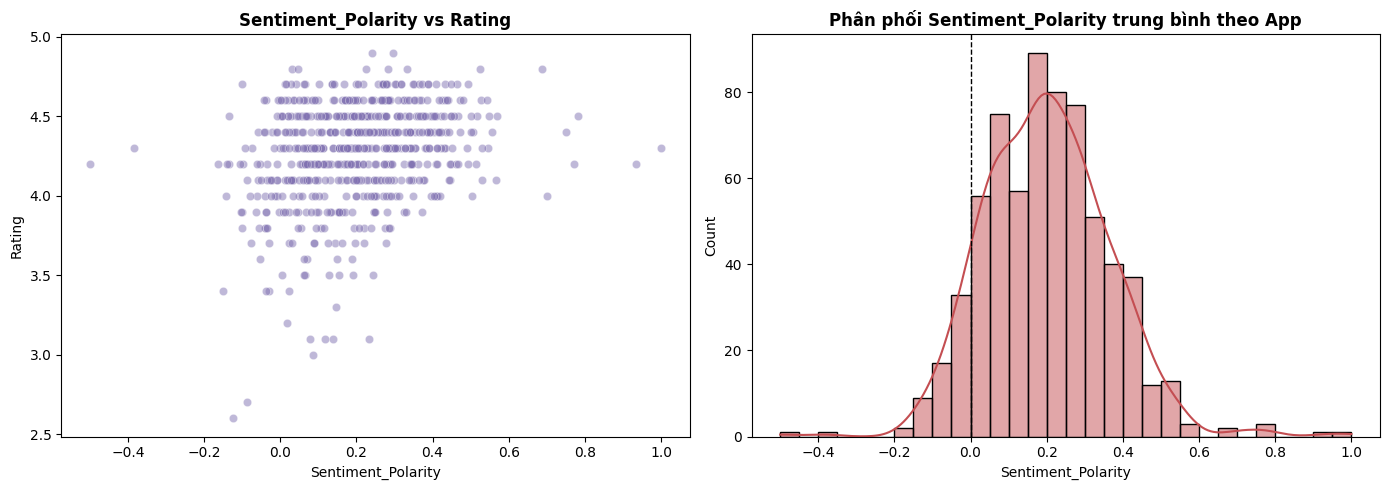

Hệ số tương quan Rating - Sentiment_Polarity (chỉ trên app có review): 0.269


In [9]:
# Chỉ xét các ứng dụng có review thực sự (Sentiment_Polarity != 0, vì 0.0 là giá trị điền khuyết)
df_has_review = df_train[df_train['Sentiment_Polarity'] != 0]
print(f"Số ứng dụng có dữ liệu Sentiment thực tế: {len(df_has_review)} / {len(df_train)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Sentiment_Polarity', y='Rating', data=df_has_review, alpha=0.5, color='#8172B2', ax=axes[0])
axes[0].set_title("Sentiment_Polarity vs Rating", fontweight='bold')

sns.histplot(df_has_review['Sentiment_Polarity'], bins=30, kde=True, color='#C44E52', ax=axes[1])
axes[1].set_title("Phân phối Sentiment_Polarity trung bình theo App", fontweight='bold')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

corr_sent = df_has_review[['Rating', 'Sentiment_Polarity']].corr().iloc[0, 1]
print(f"Hệ số tương quan Rating - Sentiment_Polarity (chỉ trên app có review): {corr_sent:.3f}")

**Nhận xét:**
- Chỉ 661/7,727 ứng dụng (≈8.6%) trong tập Train có dữ liệu review văn bản thực tế sau khi gộp từ bảng phụ; phần còn lại được điền 0.0 (giá trị trung lập/khuyết) ở Notebook 03.
- Khi chỉ xét trên nhóm có review thực tế, tương quan giữa `Sentiment_Polarity` và `Rating` tăng rõ rệt lên 0.27 (so với 0.07 khi tính trên toàn bộ tập) — xác nhận rằng cảm xúc tích cực trong review có liên hệ thuận với điểm Rating cao.
- Đây là insight quan trọng: cần tạo thêm cờ đánh dấu (flag) "có review hay không" ở bước Feature Engineering để mô hình không nhầm lẫn giá trị điền khuyết 0.0 với sentiment trung lập thật sự.

# V. Phân tích ứng dụng có lượt cài đặt vượt trội (Outliers/Top Apps)

In [10]:
top_installed = df_train.sort_values('Installs', ascending=False)[
    ['App', 'Category', 'Installs', 'Rating', 'Reviews', 'Type']
].drop_duplicates(subset='App').head(10)

print("--- TOP 10 ỨNG DỤNG CÓ LƯỢT CÀI ĐẶT LỚN NHẤT (trong tập Train) ---")
print(top_installed.to_string(index=False))

--- TOP 10 ỨNG DỤNG CÓ LƯỢT CÀI ĐẶT LỚN NHẤT (trong tập Train) ---
                          App            Category   Installs  Rating  Reviews Type
    Maps - Navigate & Explore    TRAVEL_AND_LOCAL 1000000000     4.3  9235373 Free
Skype - free IM & video calls       COMMUNICATION 1000000000     4.1 10484169 Free
            Google Play Books BOOKS_AND_REFERENCE 1000000000     3.9  1433233 Free
            Google Play Games              FAMILY 1000000000     4.3  7168735 Free
                     Facebook              SOCIAL 1000000000     4.1 78158306 Free
                      YouTube       VIDEO_PLAYERS 1000000000     4.3 25655305 Free
                        Gmail       COMMUNICATION 1000000000     4.3  4604483 Free
                    Instagram              SOCIAL 1000000000     4.5 66577446 Free
                Google Photos         PHOTOGRAPHY 1000000000     4.5 10859051 Free
           Google Street View    TRAVEL_AND_LOCAL 1000000000     4.2  2129707 Free


**Nhận xét:**
- Nhóm ứng dụng dẫn đầu về lượt cài đặt (mốc 1 tỷ+) chủ yếu thuộc các thể loại `COMMUNICATION`, `SOCIAL`, `GAME` — đúng như phát hiện ở phần III.3.
- Những ứng dụng "khổng lồ" này là các điểm dữ liệu có đòn bẩy (leverage) rất lớn có thể kéo lệch phân phối Installs, cần cân nhắc log-transform khi đưa vào mô hình hồi quy.

# VI. Tổng hợp Insight cho Feature Engineering

1. **Installs** lệch phải cực mạnh (skew ≈ 14.6) → cần biến đổi `log1p(Installs)` để chuẩn hóa phân phối.
2. **Rating** gần như không tương quan tuyến tính với các biến số gốc → cần khai thác đặc trưng phân loại (`Category`, `Genres`, `Content Rating`) qua One-Hot/Target Encoding.
3. **Sentiment_Polarity = 0.0** đang lẫn giữa "không có review" và "cảm xúc trung lập thật" → cần thêm cờ nhị phân `has_review`.
4. **Size** còn khuyết thiếu (ứng dụng `Varies with device`) → cần điền khuyết hợp lý (median theo Category) ở bước tiếp theo.
5. **Last Updated** đang ở dạng chuỗi ngày tháng → có thể trích xuất đặc trưng "số ngày kể từ lần cập nhật gần nhất" để đo độ mới của ứng dụng.
6. Thể loại (`Category`) và loại hình (`Type` Free/Paid) đều thể hiện sự khác biệt rõ rệt về Rating và Installs → là các đặc trưng phân loại có giá trị dự báo cao.

# VII. Kết luận & Sơ đồ Pipeline
- Đã khám phá đầy đủ phân phối đơn biến, tương quan đa biến và các insight quan trọng từ tập Train làm sạch.
- Các phát hiện then chốt (log-transform Installs, cờ has_review, điền khuyết Size, trích xuất đặc trưng thời gian, mã hóa biến phân loại) sẽ được hiện thực hóa cụ thể ở Notebook 05.
- **Sơ đồ Pipeline:**
  `Data Cleaning (03) -> EDA Visualization (04) -> Feature Engineering (05) -> Machine Learning (06)`